In [6]:
import YB_Pcb_Car  #Import Yahboom car library
import time
import RPi.GPIO as GPIO
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [7]:
car = YB_Pcb_Car.YB_Pcb_Car()
MSEarray = []
MAEarray = []
RMSEarray = []
Tracking_Left1 = 13   #X1B Left 1 IR sensor
Tracking_Left2 = 15   #X2B Left 2 IR sensor
Tracking_Right1 = 11   #X1A  Right 1 IR sensor
Tracking_Right2 = 7  #X2A  Right 2 IR sensor
previousError = 0
I = 0

GPIO.setmode(GPIO.BOARD)

GPIO.setwarnings(False)

GPIO.setup(Tracking_Left1,GPIO.IN)
GPIO.setup(Tracking_Left2,GPIO.IN)
GPIO.setup(Tracking_Right1,GPIO.IN)
GPIO.setup(Tracking_Right2,GPIO.IN)


In [8]:
def readBlackLine():
    # Read the input from the four tracking sensors and invert the values
    # GPIO.input() returns the current value of the specified GPIO pin.
    Tracking_Left1Value = (GPIO.input(Tracking_Left1) + 1) % 2
    Tracking_Left2Value = (GPIO.input(Tracking_Left2) + 1) % 2
    Tracking_Right1Value = (GPIO.input(Tracking_Right1) + 1) % 2
    Tracking_Right2Value = (GPIO.input(Tracking_Right2) + 1) % 2
    
    # Calculate a unique binary value for the current state of all sensors
    infraRedSensors = Tracking_Left1Value * 1 + Tracking_Left2Value * 2 + Tracking_Right1Value * 4 + Tracking_Right2Value * 8
    
    # Append the calculated sensor value to the array (assumed to be defined elsewhere)
    infraRedSensorsArray.append(infraRedSensors)
    
    try:
        # Calculate the position of the line based on weighted values of sensor states
        position = (
            Tracking_Left1Value * 0
            + Tracking_Left2Value * 2750 
            + Tracking_Right1Value * 3550
            + Tracking_Right2Value * 6300
        ) / (Tracking_Left1Value + Tracking_Left2Value + Tracking_Right1Value + Tracking_Right2Value)
    
    except ZeroDivisionError:
        # If all sensors are off, return -1 to indicate no line detected
        return -1
    
    # Return the calculated position of the line
    return position

In [9]:
Pvalue = 0
Ivalue = 0
Dvalue = 0
PIDvalue = 0
proportionalGain = 0.04
integrativeGain = 0.00002
derivativeGain = 0.035
defaultSpeed = 70

def PID_Linefollow(error):
    global I, previousError, Pvalue, Ivalue, Dvalue, PIDvalue, leftSpeed, rightSpeed
    
    prevLeftSpeedArray.append(leftSpeed)
    prevRightSpeedArray.append(rightSpeed)
    prevErrorArray.append(previousError)
     
    P = error
    I = I + error
    D = error - previousError
    
    Pvalue = P * proportionalGain
    Ivalue = I * integrativeGain
    Dvalue = D * derivativeGain
    
    PIDvalue = Pvalue + Ivalue + Dvalue
    previousError = error
    
    leftSpeed = defaultSpeed - PIDvalue
    rightSpeed = defaultSpeed + PIDvalue
    
    antiWindUp = 0
    antiWindUpGain = 0.25
    if leftSpeed > 255: antiWindUp -= leftSpeed - 255
    if leftSpeed < -255: antiWindUp -= leftSpeed + 255
    if rightSpeed > 255: antiWindUp += rightSpeed - 255
    if rightSpeed < -255: antiWindUp += rightSpeed + 255
    Ivalue = Ivalue - (antiWindUp*antiWindUpGain)
    PIDvalue = Pvalue + Ivalue + Dvalue
        
    leftSpeed = defaultSpeed - PIDvalue
    rightSpeed = defaultSpeed + PIDvalue
    
    simulationTime.append(time.time()-startTime)
    errorArray.append(error)
    pidOutput.append(PIDvalue)
    proportionalTermArray.append(Pvalue)
    integrativeTermArray.append(Ivalue)
    derivativeTermArray.append(Dvalue)
    leftSpeedArray.append(leftSpeed)
    rightSpeedArray.append(rightSpeed)
    antiWindUpArray.append(antiWindUp*antiWindUpGain)
    
    if leftSpeed > 255: leftSpeed = 255
    if leftSpeed < -255: leftSpeed = -255
    if rightSpeed > 255: rightSpeed = 255
    if rightSpeed < -255: rightSpeed = -255
    
    print("Error = ",error)
    print("Left speed =", leftSpeed, "Right speed =", rightSpeed)
        
    car.Control_Car(leftSpeed,rightSpeed)

In [11]:
startTime = time.time()
simulationTime = []
pidOutput = []
errorArray = []
proportionalTermArray = []
integrativeTermArray = []
derivativeTermArray = []
leftSpeedArray = []
rightSpeedArray = []
prevLeftSpeedArray = []
prevRightSpeedArray = []
infraRedSensors = 0
leftSpeed = 0
rightSpeed = 0
infraRedSensorsArray = []
prevErrorArray = []
antiWindUpArray = []

try:
    while True:
        tic = time.time()  # Marca o início do loop

        clear_output()
        error = 3150 - readBlackLine()
        if error == 3151:
            if previousError < 0:
                error = -6000
            else:
                error = 6000
        
        PID_Linefollow(error)

        toc = time.time()  # Marca o fim do processamento do loop
        elapsed_time = toc - tic  # Calcula o tempo que o loop levou
        sleep_time = max(1/80 - elapsed_time, 0)  # Garante que o tempo de amostragem seja 1/80 s

        time.sleep(sleep_time)  # Dorme o tempo necessário para completar a amostragem

except KeyboardInterrupt:
    pass
car.Car_Stop()

Error =  6000
Left speed = -166.51 Right speed = 255


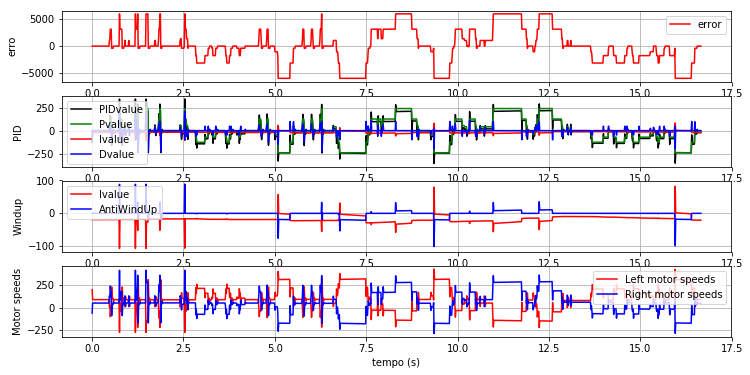

In [36]:
#%% Plot Graphs
plt.figure(figsize=(12, 6))  # Adjust the width and height values as needed
ax = plt.subplot(4,1,1)
ax.grid()
plt.plot(simulationTime,errorArray,'r',label='error')
plt.xlabel('tempo (s)')
plt.ylabel('erro')
plt.legend(loc='best')
ax = plt.subplot(4,1,2)
ax.grid()
plt.plot(simulationTime,pidOutput,'k-',label='PIDvalue')
plt.plot(simulationTime,proportionalTermArray,'g',label='Pvalue')
plt.plot(simulationTime,integrativeTermArray,'r',label='Ivalue')
plt.plot(simulationTime,derivativeTermArray,'b',label='Dvalue')
plt.xlabel('tempo (s)')
plt.ylabel('PID')
plt.legend(loc='best')
ax = plt.subplot(4,1,3)
ax.grid()
plt.plot(simulationTime,integrativeTermArray,'r',label='Ivalue')
plt.plot(simulationTime,antiWindUpArray,'b',label='AntiWindUp')
plt.xlabel('tempo (s)')
plt.ylabel('Windup')
plt.legend(loc='best')
ax = plt.subplot(4,1,4)
ax.grid()
plt.plot(simulationTime,leftSpeedArray,'r',label='Left motor speeds')
plt.plot(simulationTime,rightSpeedArray,'b',label='Right motor speeds')
plt.xlabel('tempo (s)')
plt.ylabel('Motor speeds')
plt.legend(loc='best')
plt.show()

In [37]:
car.Car_Stop()

In [38]:
# MSE: Mean Squared Error
mse = np.mean(np.square(errorArray))

# MAE: Mean Absolute Error
mae = np.mean(np.abs(errorArray))

# RMSE: Root Mean Squared Error
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print(simulationTime[-1])
# 16.62 16.37 16.04 16.33 16.66

MSE: 10272320.214876732
MAE: 2212.316362715299
RMSE: 3205.046055032085
16.65566325187683


In [39]:
MSEarray.append(mse)
MAEarray.append(mae)
RMSEarray.append(rmse)

In [41]:
print(MSEarray)
print(MAEarray)
print(RMSEarray)

[11591269.238358326, 10893186.663702575, 10500270.323599054, 10163675.986842105, 10272320.214876732]
[2383.760852407261, 2283.84781504065, 2218.8634569850037, 2186.5518575851393, 2212.316362715299]
[3404.595311980313, 3300.4827925172667, 3240.4120607723726, 3188.0520677746317, 3205.046055032085]


In [46]:
times = [16.62, 16.37, 16.04, 16.33, 16.66]
print("MSE average =", np.mean(MSEarray))
print("MSE deviation =", np.std(MSEarray))
print("MAE average =", np.mean(MAEarray))
print("MAE deviation =", np.std(MAEarray))
print("RMSE average =", np.mean(RMSEarray))
print("RMSE deviation =", np.std(RMSEarray))
print("Time average =", np.mean(times))
print("Time deviation =", np.std(times))

MSE average = 10684144.48547576
MSE deviation = 517855.2587162406
MAE average = 2257.068068946671
MAE deviation = 70.99726731698169
RMSE average = 3267.717657615334
RMSE deviation = 78.5225800946079
Time average = 16.404
Time deviation = 0.224196342521461


In [ ]:
import pandas as pd
import numpy as np

# Create a DataFrame
data = pd.DataFrame({
    'error': errorArray,
    'new_left_speed': leftSpeedArray,
    'new_right_speed': rightSpeedArray
})

data.to_csv('robot_LSTM_data.csv', index=False)

In [16]:
GPIO.cleanup()

In [17]:
import YB_Pcb_Car  #Import Yahboom car library
import time
import RPi.GPIO as GPIO
from IPython.display import clear_output
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM
import numpy as np

In [18]:
car = YB_Pcb_Car.YB_Pcb_Car()
Tracking_Left1 = 13   #X1B Left 1 IR sensor
Tracking_Left2 = 15   #X2B Left 2 IR sensor
Tracking_Right1 = 11   #X1A  Right 1 IR sensor
Tracking_Right2 = 7  #X2A  Right 2 IR sensor
previousError = 0
I = 0

GPIO.setmode(GPIO.BOARD)

GPIO.setwarnings(False)

GPIO.setup(Tracking_Left1,GPIO.IN)
GPIO.setup(Tracking_Left2,GPIO.IN)
GPIO.setup(Tracking_Right1,GPIO.IN)
GPIO.setup(Tracking_Right2,GPIO.IN)

In [19]:
infraRedSensors = 0
prevLeftSpeed = 0
prevRightSpeed = 0
infraRedSensorsArray = []
previousError = 0
inputErrorArray = np.zeros(30)

# Load the trained model
model = load_model('my_lstm_model3.h5')

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
If using Keras pass *_constraint arguments to layers.


In [71]:
startTime = time.time()
simulationTimeLSTM = []
error_list = []
emulatedPIDvalue = []
leftSpeedArrayLSTM = []
rightSpeedArrayLSTM = []

try:
    while True:
        error = 3150 - readBlackLine()
        if error == 3151:
            if previousError < 0: 
                error = -6000
            else: 
                error = 6000
                
        # Save the current error to the list
        error_list.append(error)
        
        # Shift all elements to the left
        inputErrorArray = np.roll(inputErrorArray, -1)
        # Update the last value
        inputErrorArray[-1] = error
        
        # Prepare the input data in the same format as the training data
        input_data = np.array([[inputErrorArray]]).reshape((1, 30, 1))  # Ensure input_data has the shape (1, 30, 1)
        
        # Use the model to predict new speeds
        new_speeds = model.predict(input_data)
        
        # Extract the predicted speeds
        new_left_speed, new_right_speed = new_speeds[0]
        emulatedPIDvalue.append((new_right_speed - new_left_speed) / 2)
                                
        # Constrain speeds within the acceptable range
        new_left_speed = np.clip(new_left_speed, -255, 255)
        new_right_speed = np.clip(new_right_speed, -255, 255)
        
        # Control the car with the new speeds
        car.Control_Car(new_left_speed, new_right_speed)
        
        # Update previous speeds and error
        prevLeftSpeed = new_left_speed
        prevRightSpeed = new_right_speed
        previousError = error
        
        leftSpeedArrayLSTM.append(new_left_speed)
        rightSpeedArrayLSTM.append(new_right_speed)
        
        # Calculate and save the current simulation time **after the speed prediction**
        currentTime = time.time() - startTime
        simulationTimeLSTM.append(currentTime)
        
        # Small delay for control loop
        # time.sleep(0.01)
except KeyboardInterrupt:
    pass

print("Ending")
car.Car_Stop()

Ending


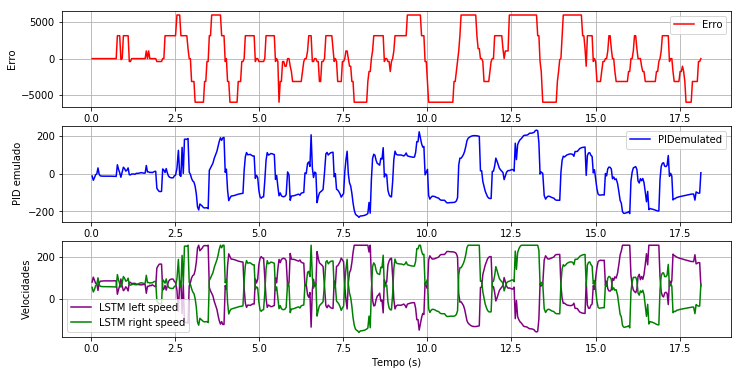

In [88]:
# Plot the error values against simulation time with a red line
plt.figure(figsize=(12, 6))  # Adjust the width and height values as needed
ax = plt.subplot(3,1,1)
ax.grid()
plt.plot(simulationTimeLSTM, error_list[:-1], label='Erro', color='red')
plt.xlabel('Tempo (s)')
plt.ylabel('Erro')
plt.legend()
ax = plt.subplot(3,1,2)
ax.grid()
plt.plot(simulationTimeLSTM, emulatedPIDvalue, label='PIDemulated', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('PID emulado')
plt.legend()
ax = plt.subplot(3,1,3)
ax.grid()
#plt.plot(simulationTime,leftSpeedArray,'r-',label='PID left speed')
plt.plot(simulationTimeLSTM, leftSpeedArrayLSTM, label='LSTM left speed', color='purple')
#plt.plot(simulationTime,rightSpeedArray,'r-',label='PID right speed')
plt.plot(simulationTimeLSTM, rightSpeedArrayLSTM, label='LSTM right speed', color='green')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidades')
plt.legend()
plt.show()

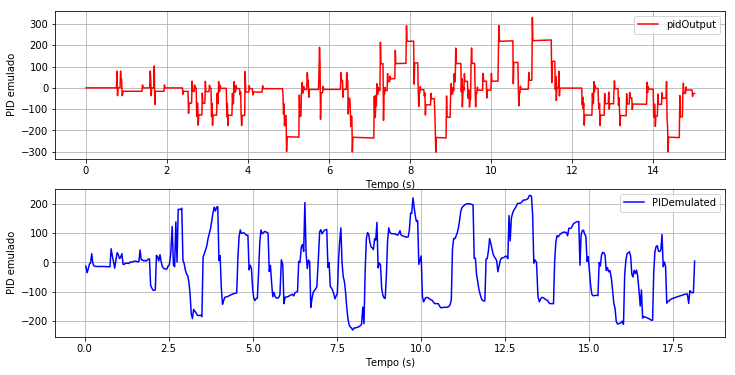

In [87]:
# Plot the error values against simulation time with a red line
plt.figure(figsize=(12, 6))  # Adjust the width and height values as needed
ax = plt.subplot(2,1,1)
ax.grid()
plt.plot(simulationTime,pidOutput,'r-',label='pidOutput')
plt.xlabel('Tempo (s)')
plt.ylabel('PID emulado')
plt.legend()
ax = plt.subplot(2,1,2)
ax.grid()
plt.plot(simulationTimeLSTM, emulatedPIDvalue, label='PIDemulated', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('PID emulado')
plt.legend()
plt.show()

In [ ]:
GPIO.cleanup()